# Set up directories 
## Setup

In this notebook, we will:

- Implement a fully vectorized loss function for the Softmax classifier.
- Derive and implement the fully vectorized analytical gradient.
- Validate the gradient implementation using numerical gradient checking.
- Use a validation set to select the learning rate and regularization strength.
- Optimize the Softmax objective using stochastic gradient descent (SGD).
- Visualize the final learned weight vectors.

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# This prints the current working directory
import os
print('Current working directory: ', os.getcwd())

Current working directory:  /content


In [ ]:
# You can use Linux commands like `pwd`, `cd` and `ls` to
# be sure about the path on which the Lab1 folder is
# Usually it should be in `/content/drive/MyDrive/labs/lab_1_2024_2025/`
# Also, make sure that the dataset cifar-10-batches-py is already downloaded!
!ls /content/drive/MyDrive/labs/

arrays	cifar-10-batches-py  lab_1_2024_2025  lab_2_2024_2025


In [ ]:
# After confirming the location of path, assign it to
# `FOLDERPATH` variable
FOLDERPATH = '/content/drive/MyDrive/labs/lab_1_2024_2025/'
assert FOLDERPATH is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.insert(1, FOLDERPATH)

In [ ]:
# Having the dataset, let's change directory to
# Lab1 folder again to continue with the exercise
%cd {FOLDERPATH}

/content/drive/MyDrive/labs/lab_1_2024_2025


In [ ]:
# Run some setup code for this notebook.
import random
import numpy as np
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 Data Loading and Pre-processing

In [ ]:
from engine.data_utils import load_CIFAR10

# Load the raw CIFAR-10 data.
cifar10_dir = '/content/drive/MyDrive/labs/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


## Load .npy files

Load dataset from ``.npy`` files! This way is really faster!

In [ ]:
# Specify project's dir, so that arrays dir is automatically retrieved and arrays can be loaded from it.
labs_dir = '/content/drive/MyDrive/labs'
arrays_dir = os.path.join(labs_dir, 'arrays')

# Load arrays if needed. Uncomment to use!
X_train = np.load(os.path.join(arrays_dir, 'full_X_train.npy'))
y_train = np.load(os.path.join(arrays_dir, 'full_y_train.npy'))
X_test = np.load(os.path.join(arrays_dir, 'full_X_test.npy'))
y_test = np.load(os.path.join(arrays_dir, 'full_y_test.npy'))

# Num of samples for training and test
num_training = X_train.shape[0]
num_test = X_test.shape[0]

## Split data

In [ ]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data.
# We can use this for development so our code runs faster.
num_training = 45000
num_validation = 5000
num_test = 10000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (45000, 32, 32, 3)
Train labels shape:  (45000,)
Validation data shape:  (5000, 32, 32, 3)
Validation labels shape:  (5000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


## Pre-process data

In [ ]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (45000, 3072)
Validation data shape:  (5000, 3072)
Test data shape:  (10000, 3072)
dev data shape:  (500, 3072)


Some of the elements of the mean image:
[130.81026667 136.10006667 132.57751111 130.21462222 135.4506
 131.84097778 131.12795556 136.25024444 132.56973333 131.65686667]
The mean image of our train set:


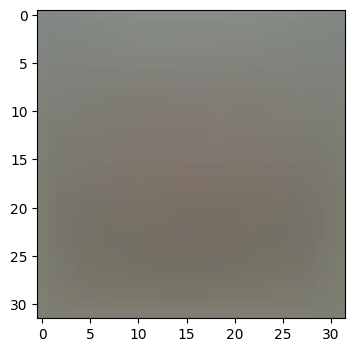

In [ ]:
# Preprocessing: subtract the mean image
# compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)

# Visualize some of its elements and the image itself
print('Some of the elements of the mean image:')
print(mean_image[:10]) # print a few of the elements
print('The mean image of our train set:')
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# subtract the mean image from train and test data
mean_image = mean_image.astype('uint8')
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# append the bias dimension of ones (i.e. bias trick) so that our SVM
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

Let's see our arrays' new shapes after bias trick.

In [ ]:
print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

(45000, 3073) (5000, 3073) (10000, 3073) (500, 3073)


## Softmax Classifier


### Forward and Backward (naive)




We write code for this section in `engine/classifiers/softmax.py` and implement the ``softmax_loss_naive()`` function.



In [ ]:
#implement the naive softmax loss function with nested loops.

from engine.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.329497
sanity check: 2.302585


We expect our loss to be close to -log(0.1). W has been initialized with very small random values, so the initial computation of the loss is based on assigning equal probability(1/10) for each class. Loss is also given by -log(softmax_prob[𝑦]) and that's why we expect a loss close to -log(0.1).

$\color{pink}{\textit Code Question:}$

We also implement the gradient in ``softmax_loss_naive()``  function, using a naive way with nested loops.

### Gradient check

In [ ]:
# Complete the implementation of softmax_loss_naive and implement a (naive)
# version of the gradient that uses nested loops.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As we did for the SVM, use numeric gradient checking as a debugging tool.
# The numeric gradient should be close to the analytic gradient.
from engine.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

# similar to SVM case, do another gradient check with regularization
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: -0.161650 analytic: -0.161650, relative error: 4.510940e-07
numerical: 2.711302 analytic: 2.711302, relative error: 3.381318e-08
numerical: -0.011221 analytic: -0.011221, relative error: 2.490575e-06
numerical: -0.804321 analytic: -0.804321, relative error: 2.686077e-08
numerical: -0.402415 analytic: -0.402415, relative error: 6.152880e-08
numerical: -1.312783 analytic: -1.312783, relative error: 1.874409e-08
numerical: -0.792900 analytic: -0.792900, relative error: 2.974613e-08
numerical: -0.160220 analytic: -0.160220, relative error: 1.940592e-07
numerical: -1.013172 analytic: -1.013172, relative error: 1.361080e-08
numerical: -0.593762 analytic: -0.593762, relative error: 1.359102e-07
numerical: -2.164652 analytic: -2.164652, relative error: 6.444413e-10
numerical: 0.218975 analytic: 0.218975, relative error: 4.026281e-08
numerical: -2.549149 analytic: -2.549149, relative error: 3.487197e-08
numerical: 1.755540 analytic: 1.755540, relative error: 4.535322e-08
numerical: 0

### Forward and Backward (vectorized)



We implement a vectorized version of the softmax loss function in ``softmax_loss_vectorized()`` function of `engine/classifiers/softmax.py` 

In [ ]:
# Now that we have a naive implementation of the softmax loss function and its gradient,
# implement a vectorized version in softmax_loss_vectorized.
# The two versions should compute the same results, but the vectorized version should be
# much faster.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from engine.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# As we did for the SVM, we use the Frobenius norm to compare the two versions
# of the gradient.
grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.329497e+00 computed in 0.096736s
vectorized loss: 2.329497e+00 computed in 0.011355s
Loss difference: 0.000000
Gradient difference: 0.000000


### Hyperparameter search

The code in the below cell chooses the best hyperparameters (regularization strength and learning rate) by tuning on the validation set (grid search). Our goal is to perform a real-world training in order to save the softmax model that performs the best on validation set.

In [ ]:
# We use the validation set to tune hyperparameters (regularization strength and
# learning rate). We experiment with different ranges for the learning
# rates and regularization strengths; we should be able to
# get a classification accuracy of over 0.35 on the validation set.

from engine.classifiers import Softmax
results = {}
best_val = -1
best_softmax = None

                                                                       
# We use the validation set to set the learning rate and regularization strength. 
# This should be identical to the validation that we did for the SVM; save    
# the best trained softmax classifer in best_softmax.                          


# Provided as a reference. You may or may not want to change these hyperparameters
learning_rates = [1e-7, 5e-7]
regularization_strengths = [2.5e4, 5e4]

for lr in learning_rates:
    for reg in regularization_strengths:
      softmax = Softmax()
      softmax.train(X_train, y_train, learning_rate=lr, reg=reg, num_iters=1500, batch_size=200, verbose=False)
      y_train_pred = softmax.predict(X_train)
      train_accuracy = np.mean(y_train_pred == y_train)
      y_val_pred = softmax.predict(X_val)
      val_accuracy = np.mean(y_val_pred == y_val)
      results[(lr, reg)] = (train_accuracy, val_accuracy)
      if val_accuracy > best_val:
        best_val = val_accuracy
        best_softmax = softmax


# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during validation: %f' % best_val)

lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.328556 val accuracy: 0.331000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.304533 val accuracy: 0.310400
lr 5.000000e-07 reg 2.500000e+04 train accuracy: 0.326578 val accuracy: 0.326200
lr 5.000000e-07 reg 5.000000e+04 train accuracy: 0.302556 val accuracy: 0.310000
best validation accuracy achieved during validation: 0.331000


### Predict on test set (unseen images)

Let's see how our model performs on unseen images - the test set.

In [ ]:
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax on raw pixels final test set accuracy: %f' % (test_accuracy, ))

softmax on raw pixels final test set accuracy: 0.335500


Assuming that the total training loss is computed as the sum of the individual losses over all training examples, it is possible for a newly added datapoint to leave the SVM loss unchanged. However, this does not generally happen with the Softmax classifier loss.

The reason is that the two losses are computed differently. The SVM loss is margin-based and only contributes when an example violates the margin. Therefore, if a new datapoint is correctly classified with a sufficient margin, it may add zero loss and leave the total SVM loss unchanged.

In contrast, the Softmax loss is probability-based. It depends on the predicted probability assigned to the correct class for every training example. As a result, every new datapoint contributes some loss, even if it is classified correctly. Therefore, adding a new training example will generally change the overall Softmax loss.

### Visualization of learned weights for each class

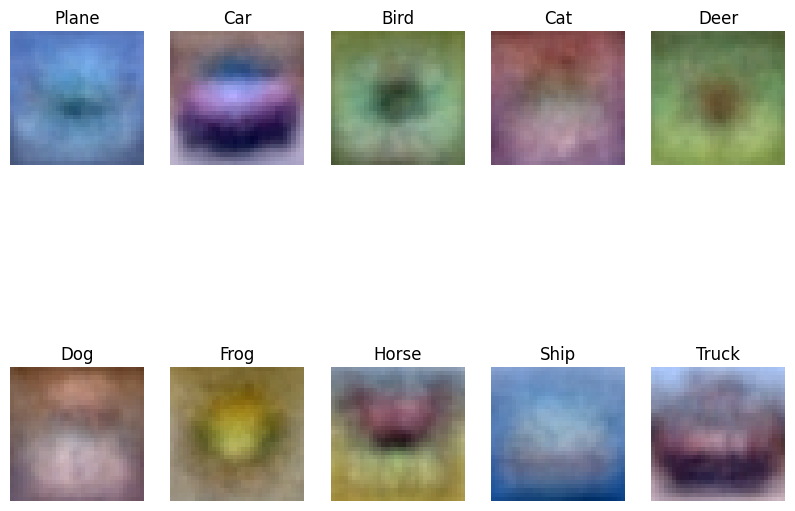

In [ ]:
# Visualize the learned weights for each class
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])